## Setup, imports and source-data loading

In [1]:
import pandas as pd
import redshift_connector
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import itertools
from scipy import stats
import base64
import io


# Enter Redshift connection details
conn_args = {
    'host': 'cm-mks-helix-cluster-1.cgv0wa0jntot.us-west-2.redshift.amazonaws.com',
    'database': 'cm_sandbox_4',
    'port': 5439,
    'user': 'tribalvw',
    'password': 'R3$h!ft35263e3f!LxLc'
        }
# Establish connection
conn = redshift_connector.connect(**conn_args)

# Direct read (No S3 staging)
query = "SELECT * FROM af_tribal.Models_Advanced_Forecasting"
input_df = pd.read_sql(query, conn) 

# Access the data directly as a Pandas DataFrame
data = input_df


ID3_df = data[data['model'] == 'ID.3']
ID3_df_sorted = ID3_df.sort_values(by='week_start', ascending=True)
ID3_df_sorted = ID3_df_sorted.iloc[1:-1]

cross_df = data[data['model'] == 'T-Cross']
cross_df_sorted = cross_df.sort_values(by='week_start', ascending=True)
cross_df_sorted = cross_df_sorted.iloc[1:-1]

ID7_df = data[data['model'] == 'ID.7']
#ID7_df['week_start'] = pd.to_datetime(ID7_df['week_start'])
ID7_df_sorted = ID7_df.sort_values(by='week_start', ascending=True)
ID7_df_sorted = ID7_df_sorted.iloc[1:-1]



#T1

from scipy.linalg import cholesky
import plotly.graph_objects as go
from plotly.subplots import make_subplots

C:\Users\JiaxinLiang(TribalWo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\JiaxinLiang(TribalWo\AppData\Local\Temp\ipykernel_6808\3515763158.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  input_df = pd.read_sql(query, conn)


## Step 1: GLOBAL CONFIGURATION & DYNAMIC WEIGHT MATRIX

In [2]:
# =====================================================================
# STEP 1: GLOBAL CONFIGURATION & DYNAMIC WEIGHT MATRIX
# =====================================================================
PRICE_PETROL = 25000       
PRICE_PREMIUM_EV = 30000   
PRICE_NEW_EV = 27000       
EV_TREND_BOOST = 0.01      

price_distance = (PRICE_NEW_EV - PRICE_PETROL) / (PRICE_PREMIUM_EV - PRICE_PETROL)
price_distance = max(0.0, min(1.0, price_distance))

W_PETROL = 1.0 - price_distance
W_PREMIUM_EV = price_distance

print("=" * 110)
print(f" INITIALISING ADVANCED FORECAST ENGINE FOR NEW EV (@ £{PRICE_NEW_EV:,})")
print(f" -> RESTORING HISTORICAL FLUCTUATIONS: Residual Variance Activation")
print("=" * 110)

c_df = cross_df_sorted.copy().sort_values(by="week_start").reset_index(drop=True)
e_df = ID3_df_sorted.copy().sort_values(by="week_start").reset_index(drop=True)
oev_df = ID7_df_sorted.copy().sort_values(by="week_start").reset_index(drop=True)

for df in [c_df, e_df, oev_df]:
    df["week_start"] = pd.to_datetime(df["week_start"])

cutoff_date = pd.to_datetime("2026-09-06")
c_df = c_df[c_df["week_start"] <= cutoff_date].reset_index(drop=True)
e_df = e_df[e_df["week_start"] <= cutoff_date].reset_index(drop=True)

kpis = ["visits", "quality_arrivals", "purchase_intents", "retailer_leads"]

for df in [c_df, e_df, oev_df]:
    for kpi in kpis:
        # Convert KPI columns to float first
        df[kpis] = df[kpis].astype("float64")

        # Replace zero / negative values with 0.01
        df[kpis] = df[kpis].mask(df[kpis] <= 0, 0.01)

 INITIALISING ADVANCED FORECAST ENGINE FOR NEW EV (@ £27,000)
 -> RESTORING HISTORICAL FLUCTUATIONS: Residual Variance Activation


## Step 2: FUNNEL CONVERSION CASCADE ON RAW DATA

In [3]:
# =====================================================================
# STEP 2: FUNNEL CONVERSION CASCADE ON RAW DATA
# =====================================================================
def get_safe_historical_conversion_ratios(df):
    return {
        "v_to_qa": (df["quality_arrivals"] / df["visits"]).median(),
        "qa_to_pi": (df["purchase_intents"] / df["quality_arrivals"]).median(),
        "pi_to_rl": (df["retailer_leads"] / df["purchase_intents"]).median()
    }

c_ratios = get_safe_historical_conversion_ratios(c_df)
e_ratios = get_safe_historical_conversion_ratios(e_df)

nev_rates = {key: (c_ratios[key] * W_PETROL) + (e_ratios[key] * W_PREMIUM_EV) for key in c_ratios}

nev_df = pd.DataFrame({"week_start": c_df["week_start"]})

# --- MODIFIED LINE BELOW: Multiplied by 0.875 to shift mean from ~12k to ~10.5k ---
nev_df["visits"] = ((c_df["visits"] * W_PETROL) + (e_df["visits"] * W_PREMIUM_EV)) #* 0.875

# Construct the raw baseline with natural week-by-week noise intact
nev_df["visits"] = (c_df["visits"] * W_PETROL) + (e_df["visits"] * W_PREMIUM_EV)
nev_df["quality_arrivals"] = nev_df["visits"] * nev_rates["v_to_qa"]
nev_df["purchase_intents"] = nev_df["quality_arrivals"] * nev_rates["qa_to_pi"]
nev_df["retailer_leads"] = nev_df["purchase_intents"] * nev_rates["pi_to_rl"]

## Step 3: TREND ISOLATION & DYNAMIC EV ACCELERATION

In [4]:
# =====================================================================
# STEP 3: TREND ISOLATION & DYNAMIC EV ACCELERATION
# =====================================================================
nev_trends = pd.DataFrame({"week_start": nev_df["week_start"]})
for kpi in kpis:
    nev_trends[kpi] = nev_df[kpi].rolling(52, center=True).mean().ffill().bfill()

# Applying the structural EV tailwind shift directly onto your trend channel
nev_trends["visits"] = nev_trends["visits"] * (1.0 + (EV_TREND_BOOST - 1.0) * W_PREMIUM_EV)

# Extracting raw seasonal variation residuals (difference between raw data and smooth trend)
nev_residuals = pd.DataFrame({"week_start": nev_df["week_start"]})
for kpi in kpis:
    nev_residuals[kpi] = nev_df[kpi] - nev_trends[kpi]

## Step 4: TARGETED UK REGISTRATION PLATE INJECTION & BASELINE INTEGRATION

In [5]:
# =====================================================================
# STEP 4: TARGETED UK REGISTRATION PLATE INJECTION & BASELINE INTEGRATION
# =====================================================================
week_numbers = nev_trends["week_start"].dt.isocalendar().week
for idx in range(len(nev_trends)):
    if week_numbers.iloc[idx] in [9, 10, 11, 12, 13, 36, 37, 38, 39]:
        nev_trends.loc[idx, "retailer_leads"] *= 1.29

# Combining the boosted trends with the organic weekly variations (residuals)
for kpi in kpis:
    nev_df[kpi] = np.abs(nev_trends[kpi] + nev_residuals[kpi])

## Step 5: FINAL CROSS-KPI COVARIANCE INTEGRATION (Cholesky Matrix)

In [6]:
# =====================================================================
# STEP 5: FINAL CROSS-KPI COVARIANCE INTEGRATION (Cholesky Matrix)
# =====================================================================
combined_corr = (c_df[kpis].corr() + e_df[kpis].corr()) / 2
chol_matrix = cholesky(combined_corr.values, lower=True)
# Increased multiplier weight to 0.15 to let natural funnel correlation wiggles shine through clearly
correlated_noise = np.dot(np.random.normal(0, 1, (len(nev_df), 4)), chol_matrix.T)

for i, kpi in enumerate(kpis):
    nev_df[kpi] = np.abs(nev_df[kpi] + (correlated_noise[:, i] * nev_df[kpi].std() * 0.15))

## Step 6: FUTURE PROPHET GENERATION & MARKETING LIFTS

In [7]:
# =====================================================================
# STEP 6: FUTURE PROPHET GENERATION & MARKETING LIFTS
# =====================================================================
MAX_CAMPAIGN_BUDGET_BENCHMARK = 450000
lift_multipliers = {"visits": 18700.0/5332.5, "quality_arrivals": 2821.0/1510.0, "purchase_intents": 1282.0/646.5, "retailer_leads": 93.0/19.0}

future_dates = pd.date_range(start="2026-09-07", end="2027-01-31", freq="W-MON")
forecast_df = pd.DataFrame({"week_start": future_dates})
known_spends = {"2026-08-08": 100000, "2026-09-07": 71000, "2026-09-11": 54000, "2026-10-14": 100000, "2026-11-12": 0}

def assign_spend(row):
    dt = row["week_start"].strftime("%Y-%m-%d")
    if dt in known_spends: return known_spends[dt]
    m = row["week_start"].month
    if m in [7]: return 75000
    if m in [9]: return 110000
    if m in [10]: return 200000
    if m in [6]: return 0       
    if m in [11, 12]: return 0     
    return 0                         
forecast_df["total_spend"] = forecast_df.apply(assign_spend, axis=1)

forecast_results = {}
summary_reporting_data = {}

for kpi in kpis:
    df_prophet = nev_df[["week_start", kpi]].rename(columns={"week_start": "ds", kpi: "y"})
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, interval_width=0.95)
    # 2. 
    # This automatically adds historical and future UK holiday effects to the model
    model.add_country_holidays(country_name='UK')
    model.fit(df_prophet)
    
    future_prophet = forecast_df.rename(columns={"week_start": "ds"}).copy()
    forecast = model.predict(future_prophet)
    forecast.loc[forecast["yhat"] < 0, "yhat"] = 0.01

    # Floor values at 0.01 to avoid negative projections across all boundaries
    for col in ["yhat", "yhat_lower", "yhat_upper"]:
        forecast.loc[forecast[col] < 0, col] = 0.01

    
    # --- Adding a factor of 10500 (desired mean) / 12000 (current mean) ---
    if kpi == "visits":
        for col in ["yhat", "yhat_lower", "yhat_upper"]:
            forecast[col] = forecast[col] * 0.875  # Deflates future base mean from ~12k to ~10.5k
    # ------------------------------------------------
    
    
    organic_mean = forecast["yhat"].mean()
    
    for idx, row in forecast.iterrows():
        m = row["ds"].month
        spend = future_prophet.loc[idx, "total_spend"]
        spend_ratio = spend / MAX_CAMPAIGN_BUDGET_BENCHMARK
        
        if row["ds"] <= pd.to_datetime("2026-09-06") or m in [6, 7, 8, 9, 10]:
            lift = (1.0 + ((lift_multipliers[kpi] - 1.0) * spend_ratio))
            for col in ["yhat", "yhat_lower", "yhat_upper"]:
                forecast.loc[idx, col] *= lift

    forecast_weeks = forecast["ds"].dt.isocalendar().week
    if kpi == "retailer_leads":
        target_weeks = [9, 10, 11, 12, 13, 36, 37, 38, 39]
        for col in ["yhat", "yhat_lower", "yhat_upper"]:
            forecast.loc[forecast_weeks.isin(target_weeks), col] *= 1.29

    forecast_results[kpi] = forecast
    
    summary_reporting_data[kpi] = {
        "Organic Baseline Mean": round(organic_mean, 2),
        "Forecast Minimum Volume": round(forecast["yhat"].min(), 2),
        "Campaign Peak Max": round(forecast["yhat"].max(), 2),
        "Absolute Peak Lift Volume": round(forecast["yhat"].max() - organic_mean, 2),
        "Peak Multiplier (x)": f"{forecast['yhat'].max() / organic_mean:.2f}x"
    }

print("\n" + "=" * 115)
print("    EXECUTIVE PERFORMANCE ROADMAP SUMMARY MATRIX (`nev_df` FORECASTS) ")
print("=" * 115)
print(pd.DataFrame(summary_reporting_data).T)
print("=" * 115)

19:52:23 - cmdstanpy - INFO - Chain [1] start processing
19:52:23 - cmdstanpy - INFO - Chain [1] done processing
19:52:24 - cmdstanpy - INFO - Chain [1] start processing
19:52:24 - cmdstanpy - INFO - Chain [1] done processing
19:52:24 - cmdstanpy - INFO - Chain [1] start processing
19:52:24 - cmdstanpy - INFO - Chain [1] done processing
19:52:25 - cmdstanpy - INFO - Chain [1] start processing
19:52:25 - cmdstanpy - INFO - Chain [1] done processing



    EXECUTIVE PERFORMANCE ROADMAP SUMMARY MATRIX (`nev_df` FORECASTS) 
                 Organic Baseline Mean Forecast Minimum Volume  \
visits                          6090.8                 4940.73   
quality_arrivals               2209.02                 1796.65   
purchase_intents               1126.75                  926.72   
retailer_leads                   46.11                   35.88   

                 Campaign Peak Max Absolute Peak Lift Volume  \
visits                    14166.04                   8075.24   
quality_arrivals           3374.69                   1165.66   
purchase_intents           1758.51                    631.76   
retailer_leads              151.47                    105.36   

                 Peak Multiplier (x)  
visits                         2.33x  
quality_arrivals               1.53x  
purchase_intents               1.56x  
retailer_leads                 3.28x  


## Step 7: DUAL-SCALED GRAPHING ENGINE WITH ORGANIC VARIANCE

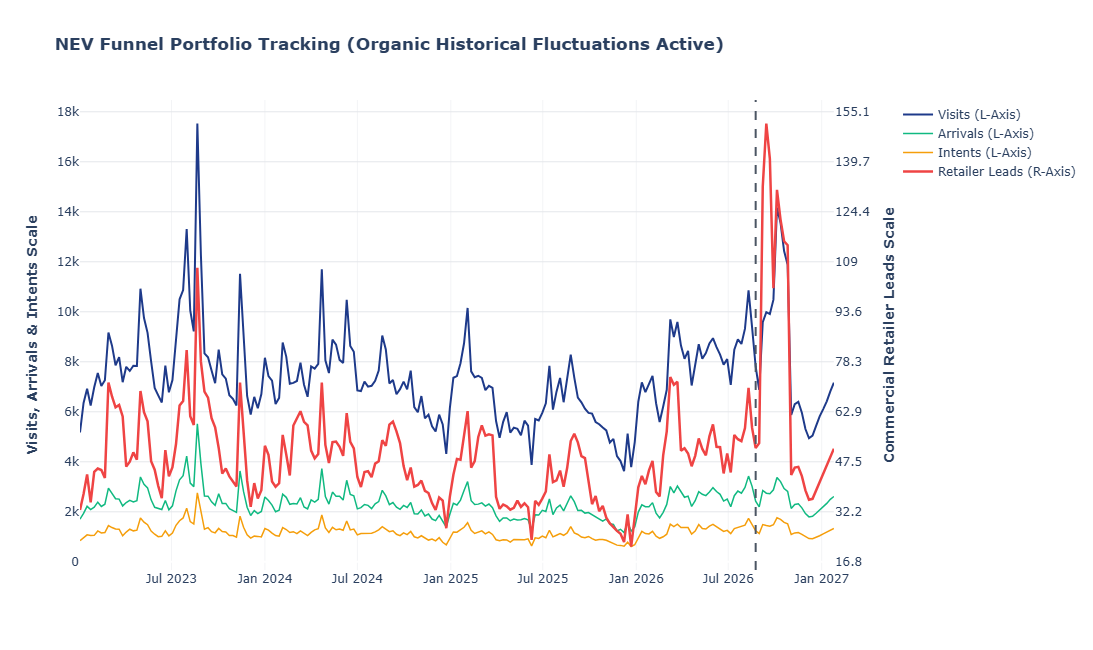

In [8]:
# =====================================================================
# STEP 7: DUAL-SCALED GRAPHING ENGINE WITH ORGANIC VARIANCE
# =====================================================================
history_plots = []
for idx, row in nev_df.iterrows():
    history_plots.append({"Date": row["week_start"], "Visits": row["visits"], "Arrivals": row["quality_arrivals"], "Intents": row["purchase_intents"], "Leads": row["retailer_leads"]})

for idx, future_date in enumerate(future_dates):
    history_plots.append({
        "Date": future_date,
        "Visits": forecast_results["visits"]["yhat"].iloc[idx],
        "Arrivals": forecast_results["quality_arrivals"]["yhat"].iloc[idx],
        "Intents": forecast_results["purchase_intents"]["yhat"].iloc[idx],
        "Leads": forecast_results["retailer_leads"]["yhat"].iloc[idx]
    })
plotly_master_df = pd.DataFrame(history_plots)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=plotly_master_df["Date"], y=plotly_master_df["Visits"], name="Visits (L-Axis)", line=dict(color="#1e3a8a", width=2)), secondary_y=False)
fig.add_trace(go.Scatter(x=plotly_master_df["Date"], y=plotly_master_df["Arrivals"], name="Arrivals (L-Axis)", line=dict(color="#10b981", width=1.5)), secondary_y=False)
fig.add_trace(go.Scatter(x=plotly_master_df["Date"], y=plotly_master_df["Intents"], name="Intents (L-Axis)", line=dict(color="#f59e0b", width=1.5)), secondary_y=False)
fig.add_trace(go.Scatter(x=plotly_master_df["Date"], y=plotly_master_df["Leads"], name="Retailer Leads (R-Axis)", line=dict(color="#ef4444", width=2.5)), secondary_y=True)

fig.add_vline(x=pd.to_datetime("2026-08-24").timestamp() * 1000, line_width=2, line_dash="dash", line_color="#4b5563")
fig.update_layout(title="<b>NEV Funnel Portfolio Tracking (Organic Historical Fluctuations Active)</b>", plot_bgcolor="white", hovermode="x unified", height=650)
fig.update_xaxes(showgrid=True, gridcolor="#f3f4f6")
fig.update_yaxes(title_text="<b>Visits, Arrivals & Intents Scale</b>", secondary_y=False, showgrid=True, gridcolor="#e5e7eb")
fig.update_yaxes(title_text="<b>Commercial Retailer Leads Scale</b>", secondary_y=True)
fig.show()



#revised extraction with lower and upper bounds

## Step 8: MERGE HISTORY & FORECAST INTO A SINGLE TIMELINE & Export CSV

In [9]:
# =====================================================================
# STEP 8: MERGE HISTORY & FORECAST INTO A SINGLE TIMELINE & Export CSV
# =====================================================================
# 1. Structure the historical data to match our output format
history_clean = nev_df[["week_start"] + kpis].copy()
history_clean["data_type"] = "Historical"

# Initialize uncertainty columns for historical data as NaN
for kpi in kpis:
    history_clean[f"{kpi}_lower"] = np.nan
    history_clean[f"{kpi}_upper"] = np.nan

# 2. Extract and align the 'yhat', 'yhat_lower', and 'yhat_upper' columns
forecast_clean = pd.DataFrame({"week_start": future_dates})
for kpi in kpis:
    kpi_forecast = forecast_results[kpi][["ds", "yhat", "yhat_lower", "yhat_upper"]].rename(
        columns={
            "ds": "week_start", 
            "yhat": kpi,
            "yhat_lower": f"{kpi}_lower",
            "yhat_upper": f"{kpi}_upper"
        }
    )
    forecast_clean = pd.merge(forecast_clean, kpi_forecast, on="week_start", how="left")
forecast_clean["data_type"] = "Forecast"

# 3. Stack history and forecast vertically into one continuous timeline
final_timeline_df = pd.concat([history_clean, forecast_clean], axis=0, ignore_index=True)

# 4. Sort chronologically and round the KPI volumes for clean reporting
final_timeline_df = final_timeline_df.sort_values(by="week_start").reset_index(drop=True)

# Round to 0 decimal places and cast to integer type
for kpi in kpis:
    # Round main forecast/historical column
    final_timeline_df[kpi] = final_timeline_df[kpi].round(0).astype(int)
    
    # Safely round forecast uncertainty bands (ignoring historical NaNs)
    final_timeline_df[f"{kpi}_lower"] = final_timeline_df[f"{kpi}_lower"].round(0).astype("Int64")
    final_timeline_df[f"{kpi}_upper"] = final_timeline_df[f"{kpi}_upper"].round(0).astype("Int64")

# 5. Export to CSV
final_timeline_df.to_csv("nev_complete_timeline.csv", index=False)

print(f"\n[SUCCESS] Continuous timeline exported to 'nev_complete_timeline.csv'")
print(f" -> Historical Rows: {len(history_clean)} | Forecast Rows: {len(forecast_clean)}")


final_output_df=final_timeline_df.copy()




import pandas as pd
import numpy as np

# List of all your KPI columns
kpis = ["visits", "purchase_intents", "quality_arrivals", "retailer_leads"]

for kpi in kpis:
    # 1. Create the _actual column (wrap np.where in pd.Series)
    actual_array = np.where(
        final_output_df["data_type"] == "Historical",
        final_output_df[kpi],
        np.nan
    )
    final_output_df[f"{kpi}_actual"] = pd.Series(actual_array).astype("Int64")
    
    # 2. Create the _yhat column (wrap np.where in pd.Series)
    yhat_array = np.where(
        final_output_df["data_type"] == "Forecast",
        final_output_df[kpi],
        np.nan
    )
    final_output_df[f"{kpi}_yhat"] = pd.Series(yhat_array).astype("Int64")

# 3. Drop the original columns now that they are split
#final_output_df = final_output_df.drop(columns=kpis)
final_output_df.info()

########### writing forecast tables into Redshift




# 1. Separate DataFrames for each KPI starting 19 Jan 2026a
IDCross_visits_forecast = final_output_df[["week_start", "visits_yhat", "visits_lower", "visits_upper", "visits_actual"]].copy()
IDCross_purchase_intents_forecast = final_output_df[["week_start", "purchase_intents_yhat", "purchase_intents_lower", "purchase_intents_upper", "purchase_intents_actual"]].copy()
IDCross_quality_arrivals_forecast = final_output_df[["week_start", "quality_arrivals_yhat", "quality_arrivals_lower", "quality_arrivals_upper", "quality_arrivals_actual" ]].copy()
IDCross_retailer_leads_forecast = final_output_df[["week_start", "retailer_leads_yhat", "retailer_leads_lower", "retailer_leads_upper", "retailer_leads_actual"]].copy()

# 2. Rename the columns to remove the 'visits_' prefix
IDCross_visits_forecast = IDCross_visits_forecast.rename(columns={
    "visits_yhat": "yhat",
    "visits_lower": "yhat_lower",
    "visits_upper": "yhat_upper",
    "visits_actual": "actual"
})

# 2a. Enforce the exact column order you requested
IDCross_visits_forecast = IDCross_visits_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]

# 3. Rename the columns to remove the 'visits_' prefix
IDCross_purchase_intents_forecast = IDCross_purchase_intents_forecast.rename(columns={
    "purchase_intents_yhat": "yhat",
    "purchase_intents_lower": "yhat_lower",
    "purchase_intents_upper": "yhat_upper",
    "purchase_intents_actual": "actual"
})

# 3a. Enforce the exact column order you requested
IDCross_purchase_intents_forecast = IDCross_purchase_intents_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]

# 4. Rename the columns to remove the 'visits_' prefix
IDCross_quality_arrivals_forecast = IDCross_quality_arrivals_forecast.rename(columns={
    "quality_arrivals_yhat": "yhat",
    "quality_arrivals_lower": "yhat_lower",
    "quality_arrivals_upper": "yhat_upper",
    "quality_arrivals_actual": "actual"
})

# 4a. Enforce the exact column order you requested
IDCross_quality_arrivals_forecast = IDCross_quality_arrivals_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]

# 5. Rename the columns to remove the 'visits_' prefix
IDCross_retailer_leads_forecast = IDCross_retailer_leads_forecast.rename(columns={
    "retailer_leads_yhat": "yhat",
    "retailer_leads_lower": "yhat_lower",
    "retailer_leads_upper": "yhat_upper",
    "retailer_leads_actual": "actual"
})

# 5a. Enforce the exact column order you requested
IDCross_retailer_leads_forecast = IDCross_retailer_leads_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]


# 6. Select relevant columns for final output/plotting
IDCross_visits_forecast = IDCross_visits_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_v = IDCross_visits_forecast.copy()
IDCross_purchase_intents_forecast = IDCross_purchase_intents_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_pi = IDCross_purchase_intents_forecast.copy()
IDCross_quality_arrivals_forecast = IDCross_quality_arrivals_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_qa = IDCross_quality_arrivals_forecast.copy()
IDCross_retailer_leads_forecast = IDCross_retailer_leads_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_rl = IDCross_retailer_leads_forecast.copy()

# with treatment for NAs

# 1. CLEANING 
forecast_v.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_v.columns
]
# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_v = forecast_v[target_cols].copy()

# 1a. CLEANING 
forecast_pi.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_pi.columns
]
# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_pi = forecast_pi[target_cols].copy()

# 1b. CLEANING 
forecast_qa.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_qa.columns
]

# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_qa = forecast_qa[target_cols].copy()

# 1c. CLEANING 
forecast_rl.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_rl.columns
]

# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_rl = forecast_rl[target_cols].copy()

import time


# 2. DATABASE OPERATIONS
try:
    conn = redshift_connector.connect(**conn_args)
    conn.autocommit = True 
    cursor = conn.cursor()

    cols_definition = "week_start TIMESTAMP, yhat FLOAT, yhat_lower FLOAT, yhat_upper FLOAT, actual FLOAT"

    # --- STEP 1: DROP, WAIT, AND CREATE TABLES ---
    tables = {
        "af_tribal.m_IDCross_Forecast_Visits": forecast_cleaned_v,
        "af_tribal.m_IDCross_Forecast_PIs": forecast_cleaned_pi,
        "af_tribal.m_IDCross_Forecast_QAs": forecast_cleaned_qa,
        "af_tribal.m_IDCross_Forecast_RLs": forecast_cleaned_rl
    }

    for table_name in tables.keys():
        cursor.execute(f"DROP TABLE IF EXISTS {table_name};")
        time.sleep(3) # Wait for Redshift catalog update
        cursor.execute(f"CREATE TABLE {table_name} ({cols_definition});")
        print(f"Table {table_name} created successfully.")
    
    conn.commit()

    # --- STEP 2: PREPARE AND INSERT DATA INDIVIDUALLY ---
    
    # A. Insert Visits
    print("Inserting data into IDCross_Forecast_Visits...")
    # FIX: Convert to standard float to turn <NA> into np.nan, then map np.nan to Python None
    df_v = forecast_cleaned_v.astype({'yhat': float, 'yhat_lower': float, 'yhat_upper': float, 'actual': float})
    df_v['week_start'] = pd.to_datetime(df_v['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_v = [tuple(None if pd.isna(item) else item for item in row) for row in df_v.to_numpy()]
    
    sql_v = f"INSERT INTO af_tribal.m_IDCross_Forecast_Visits (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_v, tuples_v)
    conn.commit()

    # B. Insert PIs
    print("Inserting data into IDCross_Forecast_PIs...")
    df_pi = forecast_cleaned_pi.astype({'yhat': float, 'yhat_lower': float, 'yhat_upper': float, 'actual': float})
    df_pi['week_start'] = pd.to_datetime(df_pi['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_pi = [tuple(None if pd.isna(item) else item for item in row) for row in df_pi.to_numpy()]
    
    sql_pi = f"INSERT INTO af_tribal.m_IDCross_Forecast_PIs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_pi, tuples_pi)
    conn.commit()

    # C. Insert QAs
    print("Inserting data into IDCross_Forecast_QAs...")
    df_qa = forecast_cleaned_qa.astype({'yhat': float, 'yhat_lower': float, 'yhat_upper': float, 'actual': float})
    df_qa['week_start'] = pd.to_datetime(df_qa['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_qa = [tuple(None if pd.isna(item) else item for item in row) for row in df_qa.to_numpy()]
    
    sql_qa = f"INSERT INTO af_tribal.m_IDCross_Forecast_QAs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_qa, tuples_qa)
    conn.commit()

    # D. Insert RLs
    print("Inserting data into IDCross_Forecast_RLs...")
    df_rl = forecast_cleaned_rl.astype({'yhat': float, 'yhat_lower': float, 'yhat_upper': float, 'actual': float})
    df_rl['week_start'] = pd.to_datetime(df_rl['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_rl = [tuple(None if pd.isna(item) else item for item in row) for row in df_rl.to_numpy()]
    
    sql_rl = f"INSERT INTO af_tribal.m_IDCross_Forecast_RLs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_rl, tuples_rl)
    conn.commit()

    print("Success: All 4 KPI forecasts pushed to Redshift.")

except Exception as e:
    print(f"Error occurred: {e}")
    raise 
finally:
    cursor.close()
    conn.close()


[SUCCESS] Continuous timeline exported to 'nev_complete_timeline.csv'
 -> Historical Rows: 192 | Forecast Rows: 21
<class 'pandas.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   week_start               213 non-null    datetime64[us]
 1   visits                   213 non-null    int64         
 2   quality_arrivals         213 non-null    int64         
 3   purchase_intents         213 non-null    int64         
 4   retailer_leads           213 non-null    int64         
 5   data_type                213 non-null    str           
 6   visits_lower             21 non-null     Int64         
 7   visits_upper             21 non-null     Int64         
 8   quality_arrivals_lower   21 non-null     Int64         
 9   quality_arrivals_upper   21 non-null     Int64         
 10  purchase_intents_lower   21 non-null     Int64       